In [1006]:
import csv, pandas as pd,numpy as np
from numpy import hstack, vstack, asarray
import matplotlib.pyplot as plt
import statistics
import scipy.stats as stats

# for peptide sequence analysis
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from isoelectric import ipc


from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lazypredict.Supervised import LazyClassifier

from sklearn.metrics import matthews_corrcoef, recall_score, accuracy_score, precision_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV


### Fasta to CSV file Conversion

In [941]:
fasta_file = "ML project Dataset\peptide\peptide.fasta"  # FASTA file path

# Open the FASTA file
with open(fasta_file, "r") as f:
    # Read the contents of the file
    fasta_data = f.read()

# Print the contents of the FASTA file
print(fasta_data)

>|toxin 1
ACSGRGSRCPPQCCMGLTCGREYPPRC
>|toxin 2
CGPCFTKDPETEKKCATCCGGIGRCFGPQCLCNRGY
>|toxin 3
MSDINATRLPHLVRYPPYVGDGTDLTLNRGEK
>|toxin 4
QKELVVTATTTCCGYNPMTSCPRCMCDSSCNKKKP
>|toxin 5
CCPFPMCYQVPHCPCC
>|toxin 6
CTENGDVCDPENHNCCSGSCLDDEDPPVCGF
>|toxin 7
CKGRGGACTKAMFICCSGSCNRGRC
>|toxin 8
SCDSEFSSEFCEQPEERICSCSTHVCCHLSSSKRDQCMTWNRCLSAQTGN
>|toxin 9
VATSEQFNKTFIELVIVVD
>|toxin 10
DGVCSNRRQCNKEVCGSSYDVAIVGA
>|toxin 11
SGSTCTCFTSTNCQGSCECLSPPGCYCSNNGIRQRGCSCTCPGT
>|toxin 12
ASNHENSKGSTRNGRHTIQECCMDPVCRLIIEKFGKDFAAALDFRRLPYR
>|toxin 13
SDGRDDEAKDERPDMYKSKRDGRCCHPACAKHFNCGR
>|toxin 14
LKCKNKVVPFLKCKNKVVPFLCYKMTLKKVTPKIKRG
>|toxin 15
KQCTSNMCSADCSPGCCIIDKLEWCTCDC
>|toxin 16
GKCGDINAPCKAECDCCGYTTCDCYWGN
>|toxin 17
TCSPAGEVCTSKSPCCTGFLCSHIGGMCHH
>|toxin 18
ACVGENKQCADWAGPHCCDGYYCTCRYFPKCICRNNN
>|toxin 19
DAADVKPVARTNEGPGRDPAPCCQHPIETCC
>|toxin 20
CYGFGEACLVLYTDCCGYCVLAVCL
>|toxin 21
TLLNILRDGDNCCIDKQGCCPW
>|toxin 22
DCQALWDYCPVPLLSSGDCCYGLICGPFVCIGW
>|toxin 23
CLSGGEVCDFLFPKCCNYCILLFCS
>|toxin 

In [942]:
def fasta_to_csv(fasta_file, csv_file):
    with open(fasta_file, 'r') as f_in, open(csv_file, 'w', newline='') as f_out:
        csv_writer = csv.writer(f_out)
        
        # header row of the CSV file
        csv_writer.writerow(['Category', 'Sequence'])
        
        header = ''
        sequence = ''
        
        for line in f_in:
            line = line.strip()
            #print(line)
            if line.startswith('>'):
                # If line starts with '>', it is a header line
                if header:
        
                    csv_writer.writerow([header, sequence])
                header = line[2:7]
                print(header)
                sequence = ''
            else:
                # Concatenate sequence lines
                #print(line)
                sequence += line
                #print(sequence)
        

        csv_writer.writerow([header, sequence])

# Example usage
fasta_file = 'ML project Dataset\peptide\peptide.fasta'
csv_file = 'ML project Dataset\peptide.csv'
fasta_to_csv(fasta_file, csv_file)

toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxin
toxi

In [943]:
peptide_data = pd.read_csv("ML project Dataset\peptide.csv")
peptide_data

,Category,Sequence
0,toxin,ACSGRGSRCPPQCCMGLTCGREYPPRC
1,toxin,CGPCFTKDPETEKKCATCCGGIGRCFGPQCLCNRGY
2,toxin,MSDINATRLPHLVRYPPYVGDGTDLTLNRGEK
3,toxin,QKELVVTATTTCCGYNPMTSCPRCMCDSSCNKKKP
4,toxin,CCPFPMCYQVPHCPCC
...,...,...
3859,non-t,EDDHHHHHHHHHGVGGGGGGGGGG
3860,non-t,MTTNTQYIYPIFTVRWLAVHALAVPTVFFLGSISAMQFIQR
3861,non-t,GILDVAKTLVGKLRNVLGI
3862,non-t,MKVLSSLASAKTRYPDCQVVRRRGRVYVICKSNPRFKAVQGRKKRR


### Dataset Check

In [944]:
def check(dataset):
  print('\n')
  print('Check Unique Values per attribute')
  print(dataset.nunique(axis=0))

  print('\n')
  print('Check Null Values per attribute')
  print(dataset.isnull().sum())

  print('\n')
  print('Value Counts of target variable')
  print(dataset['Category'].value_counts())

  print('\n')
  print('Check Duplicate samples')
  return dataset[dataset.duplicated()]

In [945]:
check(peptide_data)



Check Unique Values per attribute
Category       2
Sequence    3864
dtype: int64


Check Null Values per attribute
Category    0
Sequence    0
dtype: int64


Value Counts of target variable
toxin    1932
non-t    1932
Name: Category, dtype: int64


Check Duplicate samples


,Category,Sequence


### Conversion of Categorical Feature to Numerical

In [946]:
def cat_to_num(dataset):
    dataset['Category'] = dataset['Category'].replace(['toxin', 'non-t'], [0, 1])
    return dataset

In [947]:
peptide_data = cat_to_num(peptide_data)
peptide_data

,Category,Sequence
0,0,ACSGRGSRCPPQCCMGLTCGREYPPRC
1,0,CGPCFTKDPETEKKCATCCGGIGRCFGPQCLCNRGY
2,0,MSDINATRLPHLVRYPPYVGDGTDLTLNRGEK
3,0,QKELVVTATTTCCGYNPMTSCPRCMCDSSCNKKKP
4,0,CCPFPMCYQVPHCPCC
...,...,...
3859,1,EDDHHHHHHHHHGVGGGGGGGGGG
3860,1,MTTNTQYIYPIFTVRWLAVHALAVPTVFFLGSISAMQFIQR
3861,1,GILDVAKTLVGKLRNVLGI
3862,1,MKVLSSLASAKTRYPDCQVVRRRGRVYVICKSNPRFKAVQGRKKRR


###### Calculation of features : 
# weight, # Tiny, # Small, # Aliphatic, # Aromatic, # NonPolar, # Polar, # Charged, # Basic,
# Acidic, #pI.value, #hydrophobicity.value, #net.charge, #boman.index, #instability_index, #secondary structure fraction (3 types) 
# and percentage of 20 amino acids
# Dipeptide Composition --> 400

## Total : 18 + 20 + 400 = 438 features

In [948]:
def calculate_tiny_percentage(sequence):
  tiny_residues = set("ACGSTU")
  tiny_count = sum(1 for aa in sequence if aa in tiny_residues)
  percentage = (tiny_count / len(sequence)) * 100
  return percentage


def calculate_small_percentage(sequence):
  small_residues = set("ABCDGNPSTUV")  # Set of small amino acid codes
  small_count = sum(1 for aa in sequence if aa in small_residues)
  return (small_count / len(sequence)) * 100


def boman(seq):

  # Define the Boman scale as a dictionary
  boman_scale = {
      'L': 4.92, 'I': 4.92, 'V': 4.04, 'F': 2.98, 'M': 2.35, 'W': 2.33,
      'A': 1.81, 'C': 1.28, 'G': 0.94, 'Y': -0.14, 'T': -2.57, 'S': -3.40,
      'H': -4.66, 'Q': -5.54, 'K': -5.55, 'N': -6.64, 'E': -6.81, 'D': -8.72,
      'R': -14.92
  }

  # Split the sequence into individual amino acids
  seq_list = list(seq)

  # Calculate the sum of Boman values for the sequence
  boman_sum = sum(boman_scale.get(aa, 0) for aa in seq_list)

  # Calculate and return the Boman index
  boman_index = -1 * boman_sum / len(seq_list)
  return boman_index




def calculate_aliphatic_percentage(sequence):
  """Calculates the percentage of aliphatic amino acids (AILV) in a sequence."""
  aliphatic_residues = set("AILV")
  aliphatic_count = sum(1 for aa in sequence if aa in aliphatic_residues)
  return (aliphatic_count / len(sequence)) * 100




def calculate_aromatic_percentage(sequence):
  """Calculates the percentage of aromatic amino acids (FHWY) in a sequence."""
  aromatic_residues = set("FHWY")
  aromatic_count = sum(1 for aa in sequence if aa in aromatic_residues)
  return (aromatic_count / len(sequence)) * 100





def calculate_nonpolar_percentage(sequence):
  """Calculates the percentage of non-polar amino acids (ACFILMVWY) in a sequence."""
  nonpolar_residues = set("ACFGILMPUVWY")
  nonpolar_count = sum(1 for aa in sequence if aa in nonpolar_residues)
  return (nonpolar_count / len(sequence)) * 100




def calculate_polar_percentage(sequence):
  """Calculates the percentage of polar amino acids (CDEHKNQRST) in a sequence."""
  polar_residues = set("DEHKNQRSTZ")
  polar_count = sum(1 for aa in sequence if aa in polar_residues)
  return (polar_count / len(sequence)) * 100




def calculate_charged_amino_acid_percentage(protein_sequence):

  charged_amino_acids = ['B', 'D', 'E', 'K', 'R', 'H', 'Z']
  num_charged = sum(amino_acid in charged_amino_acids for amino_acid in protein_sequence)
  return (num_charged / len(protein_sequence)) * 100





def calculate_basic_amino_acid_percentage(protein_sequence):
  basic_amino_acids = ['H', 'K', 'R']  # Lysine (K) and Arginine (R)
  num_basic = sum(amino_acid in basic_amino_acids for amino_acid in protein_sequence)
  return (num_basic / len(protein_sequence)) * 100




def calculate_acidic_amino_acid_percentage(protein_sequence):

  acidic_amino_acids = ['B', 'D', 'E', 'Z']  # Aspartic Acid (D) and Glutamic Acid (E)
  num_acidic = sum(amino_acid in acidic_amino_acids for amino_acid in protein_sequence)
  return (num_acidic / len(protein_sequence)) * 100


# Amino acids in sheet: V, I, Y, F, W, L. Amino acids in Turn: N, P, G, S. Amino acids in helix: Q, E, M, A, L.

def struc_frac(dataset):
  s_struct = ['sheet', 'turn', 'helix']
  seqs = dataset['Sequence']
  str_list = []
  for s in seqs:
    pep_seq = ProteinAnalysis(s)
    str_list.append(pep_seq.secondary_structure_fraction())
  f_str = pd.DataFrame(str_list, columns = s_struct)  
  return f_str   


In [949]:
def properties(dataset):

    weight_list = []; hydro_list = []; ip_list = []
    tiny_list = []; small_list = []; aliphatic_list = []; aromatic_list = []; nonpolar_list = []; polar_list = []
    charged_list = []; basic_list = []; acidic_list = []; boman_list = []; per_AA_list = []; instability_list = []

    seqs = dataset['Sequence']
    for s in seqs:

        pep_seq = ProteinAnalysis(s)

        weight_list.append(pep_seq.molecular_weight())
        hydro_list.append(pep_seq.gravy())
        instability_list.append(pep_seq.instability_index())
        ip_list.append(ipc.predict_isoelectric_point(s, 'EMBOSS'))

        per_AA_list.append(pep_seq.get_amino_acids_percent())

        tiny = calculate_tiny_percentage(s)
        small = calculate_small_percentage(s)
        aliphatic = calculate_aliphatic_percentage(s)
        aromatic = calculate_aromatic_percentage(s)
        nonpolar = calculate_nonpolar_percentage(s)
        polar = calculate_polar_percentage(s)
        charged = calculate_charged_amino_acid_percentage(s)
        basic = calculate_basic_amino_acid_percentage(s)
        acidic = calculate_acidic_amino_acid_percentage(s)
        boman_ind = boman(s)

        tiny_list.append(tiny)
        small_list.append(small)
        aliphatic_list.append(aliphatic)
        aromatic_list.append(aromatic)
        nonpolar_list.append(nonpolar)
        polar_list.append(polar)
        charged_list.append(charged)
        basic_list.append(basic)
        acidic_list.append(acidic)
        boman_list.append(boman_ind)

    
    f_w = pd.DataFrame(weight_list, columns = ['weight']) 
    f_h = pd.DataFrame(hydro_list, columns = ['hydrophobicity']) 
    f_ins = pd.DataFrame(instability_list, columns = ['instability']) 
    f_ip = pd.DataFrame(ip_list, columns = ['Isoelectric']) 
    f_tiny = pd.DataFrame(tiny_list, columns = ['tiny'])  
    f_small = pd.DataFrame(small_list, columns = ['small'])
    f_ali = pd.DataFrame(aliphatic_list, columns = ['aliphatic'])
    f_aro = pd.DataFrame(aromatic_list, columns = ['aromatic']) 
    f_np = pd.DataFrame(nonpolar_list, columns = ['nonpolar']) 
    f_p = pd.DataFrame(polar_list, columns = ['polar']) 
    f_chrg = pd.DataFrame(charged_list, columns = ['charged']) 
    f_bas = pd.DataFrame(basic_list, columns = ['basic']) 
    f_acid = pd.DataFrame(acidic_list, columns = ['acidic']) 
    f_boman = pd.DataFrame(boman_list, columns = ['boman']) 
    f_AA = pd.DataFrame(per_AA_list)


    dataframe = pd.concat([peptide_data, f_w, f_h, f_ins, f_ip, f_tiny, f_small, f_ali, f_aro, f_np, f_p, f_chrg, f_bas, f_acid, f_boman, f_AA], axis = 1)
    return dataframe

In [950]:
pep_up = properties(peptide_data)
pep_up

,Category,Sequence,weight,hydrophobicity,instability,Isoelectric,tiny,small,aliphatic,aromatic,...,M,N,P,Q,R,S,T,V,W,Y
0,0,ACSGRGSRCPPQCCMGLTCGREYPPRC,2889.39,-0.52,69.49,8.39,51.85,66.67,7.41,3.70,...,0.04,0.00,0.15,0.04,0.15,0.07,0.04,0.00,0.00,0.04
1,0,CGPCFTKDPETEKKCATCCGGIGRCFGPQCLCNRGY,3847.47,-0.36,22.76,7.97,50.00,63.89,8.33,8.33,...,0.00,0.03,0.08,0.03,0.06,0.00,0.08,0.00,0.00,0.03
2,0,MSDINATRLPHLVRYPPYVGDGTDLTLNRGEK,3600.02,-0.67,26.64,7.54,25.00,56.25,25.00,9.38,...,0.03,0.06,0.09,0.00,0.09,0.03,0.09,0.06,0.00,0.06
3,0,QKELVVTATTTCCGYNPMTSCPRCMCDSSCNKKKP,3829.49,-0.49,53.47,8.38,45.71,68.57,11.43,2.86,...,0.06,0.06,0.09,0.03,0.03,0.09,0.14,0.06,0.00,0.03
4,0,CCPFPMCYQVPHCPCC,1831.28,0.59,55.43,7.03,37.50,68.75,6.25,18.75,...,0.06,0.00,0.25,0.06,0.00,0.00,0.00,0.06,0.00,0.06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,1,EDDHHHHHHHHHGVGGGGGGGGGG,2338.25,-1.65,56.03,6.80,45.83,58.33,4.17,37.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.04,0.00,0.00
3860,1,MTTNTQYIYPIFTVRWLAVHALAVPTVFFLGSISAMQFIQR,4733.55,0.73,20.65,10.12,29.27,46.34,36.59,19.51,...,0.05,0.02,0.05,0.07,0.05,0.05,0.12,0.10,0.02,0.05
3861,1,GILDVAKTLVGKLRNVLGI,1979.41,0.92,13.90,10.79,26.32,52.63,52.63,0.00,...,0.00,0.05,0.00,0.00,0.05,0.00,0.05,0.16,0.00,0.00
3862,1,MKVLSSLASAKTRYPDCQVVRRRGRVYVICKSNPRFKAVQGRKKRR,5394.41,-0.78,43.68,12.25,26.09,47.83,26.09,6.52,...,0.02,0.02,0.04,0.04,0.20,0.09,0.02,0.13,0.00,0.04


In [951]:
struct_data = struc_frac(peptide_data)  #sheet, turn, helix
struct_data

,sheet,turn,helix
0,0.15,0.37,0.11
1,0.19,0.31,0.22
2,0.25,0.38,0.38
3,0.26,0.29,0.26
4,0.06,0.25,0.19
...,...,...,...
3859,0.04,0.54,0.04
3860,0.22,0.15,0.56
3861,0.37,0.26,0.53
3862,0.26,0.22,0.28


In [952]:
net_charge_df = pd.read_csv('ML project Dataset/netchargedata.csv')
net_charge_df = net_charge_df['V1']
net_charge_df = pd.DataFrame(net_charge_df)
net_charge_df.columns = ['net_charge']
net_charge_df


,net_charge
0,2.79
1,1.73
2,0.22
3,2.79
4,0.03
...,...
3859,-0.86
3860,2.21
3861,1.98
3862,13.91


In [953]:
dc_df = pd.read_csv('ML project Dataset/dcdata.csv')
dc_df = dc_df.iloc[: , 1:]
dc_df

,AA,RA,NA_dipeptide,DA,CA,EA,QA,GA,HA,IA,...,LV,KV,MV,FV,PV,SV,TV,WV,YV,VV
0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00
3,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03
4,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3860,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00
3861,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3862,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02


In [954]:
pep_final = pd.concat([pep_up, struct_data, net_charge_df, dc_df], axis = 1)
pep_final

,Category,Sequence,weight,hydrophobicity,instability,Isoelectric,tiny,small,aliphatic,aromatic,...,LV,KV,MV,FV,PV,SV,TV,WV,YV,VV
0,0,ACSGRGSRCPPQCCMGLTCGREYPPRC,2889.39,-0.52,69.49,8.39,51.85,66.67,7.41,3.70,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,0,CGPCFTKDPETEKKCATCCGGIGRCFGPQCLCNRGY,3847.47,-0.36,22.76,7.97,50.00,63.89,8.33,8.33,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,0,MSDINATRLPHLVRYPPYVGDGTDLTLNRGEK,3600.02,-0.67,26.64,7.54,25.00,56.25,25.00,9.38,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00
3,0,QKELVVTATTTCCGYNPMTSCPRCMCDSSCNKKKP,3829.49,-0.49,53.47,8.38,45.71,68.57,11.43,2.86,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03
4,0,CCPFPMCYQVPHCPCC,1831.28,0.59,55.43,7.03,37.50,68.75,6.25,18.75,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,1,EDDHHHHHHHHHGVGGGGGGGGGG,2338.25,-1.65,56.03,6.80,45.83,58.33,4.17,37.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3860,1,MTTNTQYIYPIFTVRWLAVHALAVPTVFFLGSISAMQFIQR,4733.55,0.73,20.65,10.12,29.27,46.34,36.59,19.51,...,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00
3861,1,GILDVAKTLVGKLRNVLGI,1979.41,0.92,13.90,10.79,26.32,52.63,52.63,0.00,...,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3862,1,MKVLSSLASAKTRYPDCQVVRRRGRVYVICKSNPRFKAVQGRKKRR,5394.41,-0.78,43.68,12.25,26.09,47.83,26.09,6.52,...,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02


In [955]:
col_name = list(pep_final.columns)
len(col_name)          # 438 features 

440

In [956]:
#### Null Value Check

pep_final[pep_final.isnull().any(axis=1)]

,Category,Sequence,weight,hydrophobicity,instability,Isoelectric,tiny,small,aliphatic,aromatic,...,LV,KV,MV,FV,PV,SV,TV,WV,YV,VV


## Model Training

In [957]:
X = pep_final.iloc[:, 2:]
y = pep_final['Category']

X.shape, y.shape

((3864, 438), (3864,))

In [958]:
X

,weight,hydrophobicity,instability,Isoelectric,tiny,small,aliphatic,aromatic,nonpolar,polar,...,LV,KV,MV,FV,PV,SV,TV,WV,YV,VV
0,2889.39,-0.52,69.49,8.39,51.85,66.67,7.41,3.70,66.67,33.33,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,3847.47,-0.36,22.76,7.97,50.00,63.89,8.33,8.33,63.89,36.11,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3600.02,-0.67,26.64,7.54,25.00,56.25,25.00,9.38,53.12,46.88,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00
3,3829.49,-0.49,53.47,8.38,45.71,68.57,11.43,2.86,48.57,51.43,...,0.03,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.03
4,1831.28,0.59,55.43,7.03,37.50,68.75,6.25,18.75,87.50,12.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3859,2338.25,-1.65,56.03,6.80,45.83,58.33,4.17,37.50,50.00,50.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3860,4733.55,0.73,20.65,10.12,29.27,46.34,36.59,19.51,65.85,34.15,...,0.00,0.00,0.00,0.00,0.00,0.00,0.05,0.00,0.00,0.00
3861,1979.41,0.92,13.90,10.79,26.32,52.63,52.63,0.00,68.42,31.58,...,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3862,5394.41,-0.78,43.68,12.25,26.09,47.83,26.09,6.52,47.83,52.17,...,0.00,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.02


In [859]:
X_arr = X.to_numpy()
y_arr = y.to_numpy()

print(X_arr.shape, y_arr.shape)

(3864, 438) (3864,)


In [860]:
X_data, X_test, y_data, y_test = train_test_split(X_arr, y_arr, test_size = 0.15, shuffle = True, random_state = 12)

print('Shape of 85% Dataset : ', X_data.shape, y_data.shape)
print('Shape of 15% Test Dataset : ', X_test.shape, y_test.shape)

Shape of 85% Dataset :  (3284, 438) (3284,)
Shape of 15% Test Dataset :  (580, 438) (580,)


In [861]:
X_data_df = pd.DataFrame(X_data, columns = col_name[2:])
y_data_df = pd.DataFrame(y_data)

X_test_df = pd.DataFrame(X_test, columns = col_name[2:])
y_test_df = pd.DataFrame(y_test)

In [862]:
X_test_df

,weight,hydrophobicity,instability,Isoelectric,tiny,small,aliphatic,aromatic,nonpolar,polar,...,LV,KV,MV,FV,PV,SV,TV,WV,YV,VV
0,5727.50,-0.87,10.35,7.73,28.00,54.00,16.00,8.00,52.00,48.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.02,0.00
1,3109.68,0.89,28.37,6.45,32.26,54.84,48.39,3.23,74.19,25.81,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,3101.56,0.09,50.65,7.73,55.17,72.41,13.79,10.34,62.07,37.93,...,0.00,0.00,0.00,0.00,0.04,0.00,0.04,0.00,0.00,0.00
3,5291.31,0.40,24.37,7.98,42.55,57.45,23.40,12.77,61.70,38.30,...,0.00,0.00,0.00,0.00,0.00,0.00,0.02,0.00,0.00,0.00
4,4360.80,-0.94,93.67,4.39,40.00,60.00,20.00,0.00,45.00,55.00,...,0.00,0.00,0.00,0.00,0.03,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,3209.71,-0.21,59.95,8.14,50.00,57.14,17.86,21.43,50.00,50.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
576,3098.79,-1.11,16.81,11.11,8.00,20.00,20.00,12.00,40.00,60.00,...,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
577,4220.79,-0.17,25.31,7.13,38.46,61.54,28.21,5.13,51.28,48.72,...,0.00,0.00,0.00,0.03,0.00,0.00,0.03,0.00,0.00,0.00
578,2208.70,0.25,63.53,8.62,42.11,63.16,15.79,10.53,73.68,26.32,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [863]:
y_test_df.value_counts()

0    302
1    278
dtype: int64

#### LazyPredict

In [864]:
kFold = StratifiedKFold(n_splits = 5,random_state = 12,shuffle = True)

model_out_fold = []
for train_index, val_index in kFold.split(X_data, y_data):

    X_train, X_val, y_train, y_val = X_data[train_index], X_data[val_index], y_data[train_index], y_data[val_index]
    print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)
    model_lz_clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric = matthews_corrcoef)
    models, predictions = model_lz_clf.fit(X_train, X_val, y_train, y_val)

    model_out_fold.append(models)

(2627, 438) (657, 438) (2627,) (657,)


 97%|█████████▋| 28/29 [00:31<00:00,  1.21it/s]

[LightGBM] [Info] Number of positive: 1323, number of negative: 1304
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.019974 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 19116
[LightGBM] [Info] Number of data points in the train set: 2627, number of used features: 437
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503616 -> initscore=0.014465
[LightGBM] [Info] Start training from score 0.014465


100%|██████████| 29/29 [00:32<00:00,  1.13s/it]


(2627, 438) (657, 438) (2627,) (657,)


...

100%|██████████| 29/29 [00:30<00:00,  1.06s/it]


(2628, 438) (656, 438) (2628,) (656,)


 97%|█████████▋| 28/29 [00:32<00:00,  1.01it/s]

[LightGBM] [Info] Number of positive: 1324, number of negative: 1304
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011736 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 19192
[LightGBM] [Info] Number of data points in the train set: 2628, number of used features: 437
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503805 -> initscore=0.015221
[LightGBM] [Info] Start training from score 0.015221


100%|██████████| 29/29 [00:33<00:00,  1.17s/it]


In [1005]:
model_out_fold[3]

,Accuracy,Balanced Accuracy,ROC AUC,F1 Score,matthews_corrcoef,Time Taken
Model,,,,,,
XGBClassifier,0.94,0.94,0.94,0.94,0.88,0.95
ExtraTreesClassifier,0.93,0.93,0.93,0.93,0.86,1.55
LGBMClassifier,0.93,0.93,0.93,0.93,0.86,0.87
RandomForestClassifier,0.92,0.92,0.92,0.92,0.85,2.23
BaggingClassifier,0.91,0.91,0.91,0.91,0.82,4.81
SVC,0.90,0.90,0.90,0.90,0.81,1.79
RidgeClassifierCV,0.90,0.90,0.90,0.90,0.80,0.85
LinearDiscriminantAnalysis,0.89,0.89,0.89,0.89,0.79,1.00
RidgeClassifier,0.89,0.89,0.89,0.89,0.78,0.13


#### Feature Importance

In [870]:
def cross_entropy(y_true, y_pred, n_cls):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    n_classes = n_cls 

    if y_true.ndim == 1:                    # Binary classification (assume 0/1 labels)
        y_true = np.eye(n_classes)[y_true]  # Convert to one-hot encoding
    loss = -np.sum(y_true * np.log2(y_pred)) / len(y_true)    
    return loss


    #  """
    # Calculates the cross-entropy loss between true labels and predicted probabilities.

    # Args:
    #     y_true: Array of true labels (one-hot encoded for multi-class).
    #     y_pred: Array of predicted probabilities.
    #     eps: Epsilon value to prevent log(0) errors.

    # Returns:
    #     Cross-entropy loss value.
    # """

In [871]:
def aic_clf(y_true, y_pred, k, n_cls, **kwargs):
    """
    Calculates the AIC (Akaike Information Criterion) for a classifier.

    Args:
        y_true: Array of true labels (one-hot encoded for multi-class).
        y_pred: Array of predicted probabilities.
        k: Number of estimated parameters in the model.
        **kwargs: Additional keyword arguments for the cross_entropy function.

    Returns:
        AIC value.
    """

    H = cross_entropy(y_true, y_pred, n_cls, **kwargs)
    AIC = 2 * np.log2(2) * len(y_true) * H + 2 * k
    return AIC


In [872]:
xgb_feat_imp = XGBClassifier(n_estimators = 10000, n_random_state = 12)
xgb_feat_imp.fit(X_data_df, y_data)

feat_importances = pd.Series(xgb_feat_imp.feature_importances_, index = X_data_df.columns)
feat_importances_sorted = feat_importances.sort_values(ascending = False)
var_imp = feat_importances_sorted[feat_importances_sorted >= 0]
var_imp

IN   0.05
WY   0.03
VC   0.03
CC   0.02
KN   0.02
     ... 
FD   0.00
MM   0.00
FM   0.00
PM   0.00
VV   0.00
Length: 438, dtype: float32

In [873]:
var_subset_res = []

# Loop through features in order of importance

for i in range(1, len(var_imp) + 1):
    print(i)

    # Select features
    selected_features = var_imp.index[:i]
    predictor_variables = X_data_df[selected_features]
    response_variable = pd.DataFrame(y_data)

    # Train a random forest with the selected features
    xgb_subset = XGBClassifier(n_estimators = 1000, random_state = 12)
    xgb_subset.fit(predictor_variables, response_variable)

    # Predict probabilities and calculate accuracy
    y_pred_proba = xgb_subset.predict_proba(predictor_variables)[:, 1]  
    xgb_pred = xgb_subset.predict(predictor_variables)
    acc = accuracy_score(response_variable, y_pred)

    # Calculate AIC (using cross_entropy and number of features as k)
    aic = aic_clf(response_variable, pd.DataFrame(y_pred_proba), k=i, n_cls = 2)

    var_subset_res.append({"acc": acc, "aic": aic})

# Convert results to a DataFrame
var_subset_res_df = pd.DataFrame(var_subset_res)


print(var_subset_res_df)

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


In [876]:
# for i in range(var_subset_res_df.shape[0]):

#     aic_str = str(var_subset_res_df.loc[i, 'aic'])
#     aic_str = aic_str.split()
#     aic_str = aic_str[1]
#     aic_str = aic_str.strip('"')
#     var_subset_res_df.loc[i, 'aic'] = float(aic_str)


In [974]:
var_subset_res_df

,acc,aic
0,1.00,3208.27
1,1.00,3176.78
2,1.00,2897.13
3,1.00,1404.94
4,1.00,1345.94
...,...,...
433,1.00,873.98
434,1.00,875.98
435,1.00,877.98
436,1.00,879.98


In [975]:
print('min_value_aic : ', min(var_subset_res_df['aic']))
print('index of min_value_aic : ', np.argmin(var_subset_res_df[['aic']]))

min_value_aic :  183.84
index of min_value_aic :  53


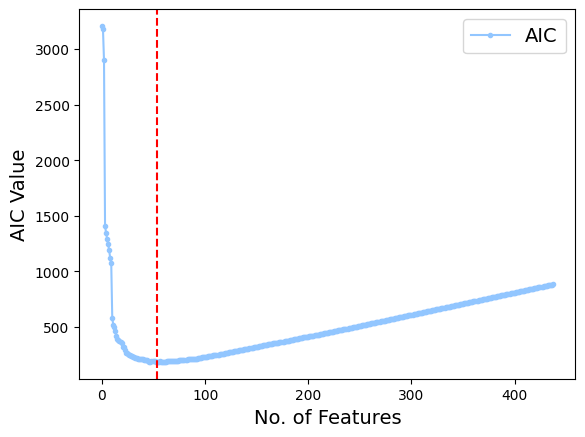

In [899]:
plt.rcParams.update(plt.rcParamsDefault)
%matplotlib inline
plt.style.use('seaborn-pastel')
plt.plot(np.arange(0, var_subset_res_df.shape[0]), var_subset_res_df[['aic']], marker="o", linestyle="-", markersize=3)
plt.axvline(x = 53, color="red", linestyle="--")
plt.legend(['AIC'], fontsize = 14) 
plt.xlabel('No. of Features', fontsize=14)
plt.ylabel('AIC Value', fontsize=14)
#plt.savefig('AIC.png',format='png')
plt.show()


In [976]:
var_imp_data = pd.DataFrame(var_imp[0:53,])

In [977]:
var_imp_data.index

Index(['IN', 'WY', 'VC', 'CC', 'KN', 'ET', 'TP', 'RE', 'KQ', 'DR', 'C', 'CY',
       'QF', 'AN', 'IC', 'CP', 'HD', 'DS', 'CF', 'TF', 'AK', 'YQ', 'GC', 'CG',
       'CQ', 'RY', 'EY', 'NC', 'SS', 'EC', 'SC', 'CE', 'LS', 'QN', 'HC', 'IG',
       'DV', 'PK', 'PV', 'MN', 'FE', 'EE', 'EV', 'QV', 'PC', 'SR', 'NT', 'SY',
       'YC', 'QL', 'SD', 'KM', 'HL'],
      dtype='object')

#### Optimizing Xgboost

In [978]:
X_imp_arr = X_data_df.loc[:, var_imp_data.index].to_numpy()

In [979]:
X_imp_arr.shape

(3284, 53)

In [980]:
# Define the hyperparameter distributions
param_dist = {
    'max_depth': [4, 5, 6],
    'min_child_weight':[4, 5, 6],
    'n_estimators': [10, 50, 100, 200, 1000],
    'learning_rate': [0.01, 0.1, 0.3, 0.5]
}

# Create the XGBoost model object
xgb_model = XGBClassifier()

# Create the RandomizedSearchCV object
random_search = RandomizedSearchCV(xgb_model, param_distributions = param_dist, n_iter = 10, cv = 5, scoring='accuracy', random_state = 12)

# Fit the RandomizedSearchCV object to the training data
random_search.fit(X_imp_arr, y_data)

# Print the best set of hyperparameters and the corresponding score
print("Best set of hyperparameters: ", random_search.best_params_)
print("Best score: ", random_search.best_score_)

Best set of hyperparameters:  {'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1}
Best score:  0.9037699075620893


[0]	validation_0-logloss:0.63051	validation_1-logloss:0.63545
[1]	validation_0-logloss:0.57723	validation_1-logloss:0.58693
[2]	validation_0-logloss:0.53285	validation_1-logloss:0.54757
[3]	validation_0-logloss:0.49613	validation_1-logloss:0.51466
[4]	validation_0-logloss:0.46375	validation_1-logloss:0.48627
[5]	validation_0-logloss:0.43554	validation_1-logloss:0.46230
[6]	validation_0-logloss:0.41226	validation_1-logloss:0.44281
[7]	validation_0-logloss:0.39086	validation_1-logloss:0.42574
[8]	validation_0-logloss:0.37284	validation_1-logloss:0.41126
[9]	validation_0-logloss:0.35674	validation_1-logloss:0.39961
[10]	validation_0-logloss:0.34175	validation_1-logloss:0.38920
[11]	validation_0-logloss:0.32958	validation_1-logloss:0.38076
[12]	validation_0-logloss:0.31815	validation_1-logloss:0.37314
[13]	validation_0-logloss:0.30780	validation_1-logloss:0.36578
[14]	validation_0-logloss:0.29829	validation_1-logloss:0.35830
[15]	validation_0-logloss:0.28982	validation_1-logloss:0.35402
[1

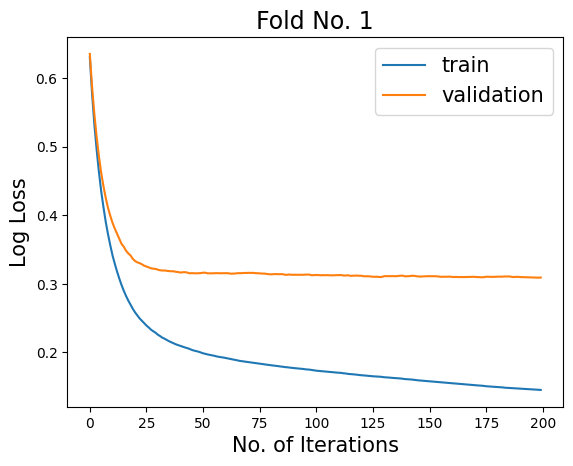

[0]	validation_0-logloss:0.63127	validation_1-logloss:0.63470
[1]	validation_0-logloss:0.57838	validation_1-logloss:0.58579
[2]	validation_0-logloss:0.53462	validation_1-logloss:0.54616
[3]	validation_0-logloss:0.49883	validation_1-logloss:0.51265
[4]	validation_0-logloss:0.46707	validation_1-logloss:0.48508
[5]	validation_0-logloss:0.43959	validation_1-logloss:0.45968
[6]	validation_0-logloss:0.41582	validation_1-logloss:0.43943
[7]	validation_0-logloss:0.39416	validation_1-logloss:0.42058
[8]	validation_0-logloss:0.37552	validation_1-logloss:0.40555
[9]	validation_0-logloss:0.35985	validation_1-logloss:0.39152
[10]	validation_0-logloss:0.34528	validation_1-logloss:0.38023
[11]	validation_0-logloss:0.33245	validation_1-logloss:0.37037
[12]	validation_0-logloss:0.32154	validation_1-logloss:0.36183
[13]	validation_0-logloss:0.31155	validation_1-logloss:0.35338
[14]	validation_0-logloss:0.30209	validation_1-logloss:0.34617
[15]	validation_0-logloss:0.29421	validation_1-logloss:0.34034
[1

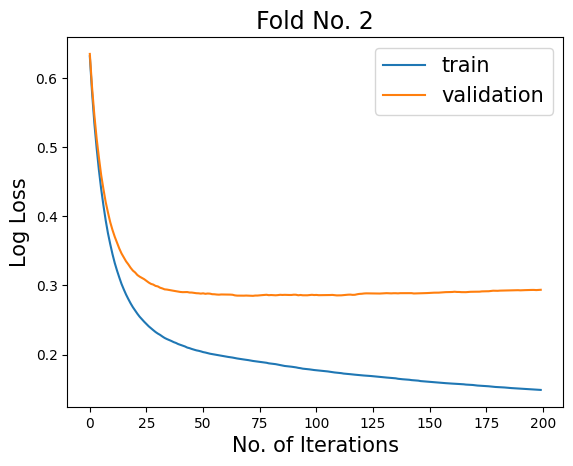

[0]	validation_0-logloss:0.63157	validation_1-logloss:0.63390
[1]	validation_0-logloss:0.58101	validation_1-logloss:0.58573
[2]	validation_0-logloss:0.53887	validation_1-logloss:0.54576
[3]	validation_0-logloss:0.50327	validation_1-logloss:0.51233
[4]	validation_0-logloss:0.47103	validation_1-logloss:0.48352
[5]	validation_0-logloss:0.44334	validation_1-logloss:0.45796
[6]	validation_0-logloss:0.41884	validation_1-logloss:0.43473
[7]	validation_0-logloss:0.39722	validation_1-logloss:0.41619
[8]	validation_0-logloss:0.37863	validation_1-logloss:0.39836
[9]	validation_0-logloss:0.36331	validation_1-logloss:0.38377
[10]	validation_0-logloss:0.34967	validation_1-logloss:0.37088
[11]	validation_0-logloss:0.33776	validation_1-logloss:0.35995
[12]	validation_0-logloss:0.32578	validation_1-logloss:0.34923
[13]	validation_0-logloss:0.31481	validation_1-logloss:0.33985
[14]	validation_0-logloss:0.30564	validation_1-logloss:0.33187
[15]	validation_0-logloss:0.29701	validation_1-logloss:0.32543
[1

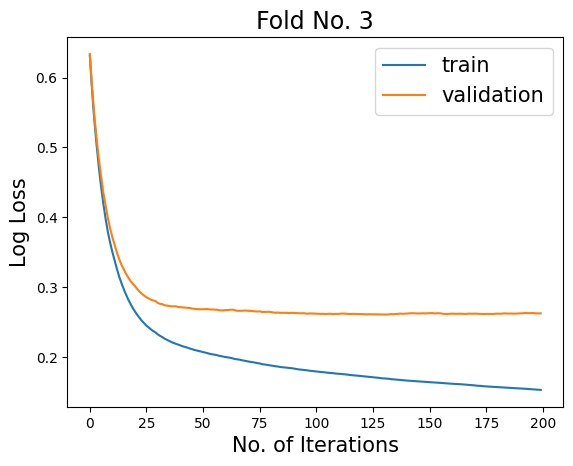

[0]	validation_0-logloss:0.63134	validation_1-logloss:0.63310
[1]	validation_0-logloss:0.58058	validation_1-logloss:0.58381
[2]	validation_0-logloss:0.53810	validation_1-logloss:0.54279
[3]	validation_0-logloss:0.50206	validation_1-logloss:0.50763
[4]	validation_0-logloss:0.47174	validation_1-logloss:0.47881
[5]	validation_0-logloss:0.44539	validation_1-logloss:0.45297
[6]	validation_0-logloss:0.42181	validation_1-logloss:0.43072
[7]	validation_0-logloss:0.40207	validation_1-logloss:0.41106
[8]	validation_0-logloss:0.38349	validation_1-logloss:0.39303
[9]	validation_0-logloss:0.36750	validation_1-logloss:0.37795
[10]	validation_0-logloss:0.35322	validation_1-logloss:0.36370
[11]	validation_0-logloss:0.34046	validation_1-logloss:0.35258
[12]	validation_0-logloss:0.32993	validation_1-logloss:0.34235
[13]	validation_0-logloss:0.32076	validation_1-logloss:0.33395
[14]	validation_0-logloss:0.31249	validation_1-logloss:0.32552
[15]	validation_0-logloss:0.30505	validation_1-logloss:0.31867
[1

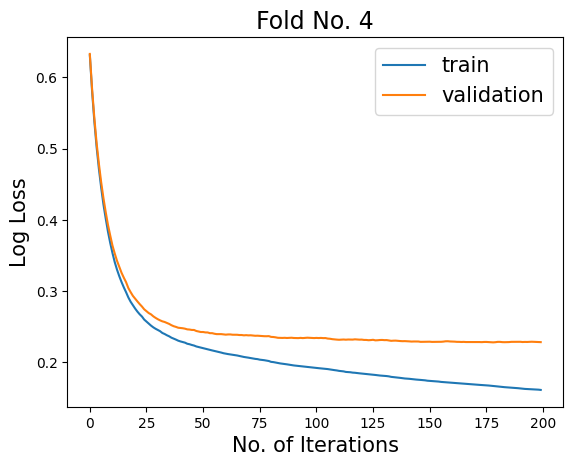

[0]	validation_0-logloss:0.63251	validation_1-logloss:0.63140
[1]	validation_0-logloss:0.58306	validation_1-logloss:0.58224
[2]	validation_0-logloss:0.54136	validation_1-logloss:0.54018
[3]	validation_0-logloss:0.50422	validation_1-logloss:0.50294
[4]	validation_0-logloss:0.47336	validation_1-logloss:0.47135
[5]	validation_0-logloss:0.44587	validation_1-logloss:0.44451
[6]	validation_0-logloss:0.42316	validation_1-logloss:0.42106
[7]	validation_0-logloss:0.40230	validation_1-logloss:0.40081
[8]	validation_0-logloss:0.38470	validation_1-logloss:0.38427
[9]	validation_0-logloss:0.36847	validation_1-logloss:0.36842
[10]	validation_0-logloss:0.35495	validation_1-logloss:0.35485
[11]	validation_0-logloss:0.34223	validation_1-logloss:0.34244
[12]	validation_0-logloss:0.33157	validation_1-logloss:0.33122
[13]	validation_0-logloss:0.32225	validation_1-logloss:0.32161
[14]	validation_0-logloss:0.31283	validation_1-logloss:0.31147
[15]	validation_0-logloss:0.30439	validation_1-logloss:0.30322
[1

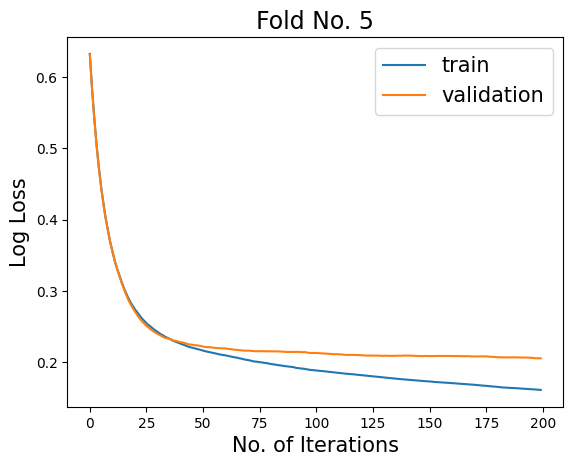

In [981]:
kFold = StratifiedKFold(n_splits = 5,random_state = 12,shuffle = True)
xgb_lr = XGBClassifier(n_estimators = 200, min_child_weight = 5, max_depth = 6, learning_rate = 0.1, random_state = 12)

folds = [] 
for train_index, val_index in kFold.split(X_imp_arr , y_data):
    folds.append(KFold)
    X_train, X_val, y_train, y_val = X_imp_arr[train_index], X_imp_arr[val_index], y_data[train_index], y_data[val_index]
    evalset = [(X_train, y_train), (X_val, y_val)]
    xgb_lr.fit(X_train, y_train, eval_metric = 'logloss', eval_set = evalset)
    y_val_pred = xgb_lr.predict(X_val)
    results = xgb_lr.evals_result()
    epochs = len(results['validation_0']['logloss'])
    plt.rcParams.update(plt.rcParamsDefault)
    %matplotlib inline
    plt.plot(range(0, epochs), results['validation_0']['logloss'], label='train')
    plt.plot(range(0, epochs), results['validation_1']['logloss'], label='validation')
    plt.legend(fontsize = 15)
    plt.xlabel('No. of Iterations',fontsize = 15)
    plt.ylabel('Log Loss', fontsize = 15)
    plt.title('Fold No. {}'.format(len(folds)), fontsize = 17)
    #plt.savefig('LR_{}.png'.format(len(folds)),format='png')
    plt.show()

#### Super Learner

In [991]:
models = list()
models.append(LogisticRegression(solver='liblinear'))
models.append(LGBMClassifier())
models.append(XGBClassifier(n_estimators = 200, min_child_weight = 5, max_depth = 6, learning_rate = 0.1, random_state = 12))
models.append(ExtraTreesClassifier())
models.append(RandomForestClassifier())
models.append(SVC(probability=True))

In [992]:
# collect out of fold predictions form k-fold cross validation
def out_of_fold_pred_base_model(X, y, models):
	meta_X, meta_y = list(), list()
	# define split of data
	kfold = StratifiedKFold(n_splits = 10, shuffle=True, random_state = 12)
	# enumerate splits
	for train_ix, test_ix in kfold.split(X, y):
		fold_yhats = list()
		# get data
		train_X, test_X = X[train_ix], X[test_ix]
		train_y, test_y = y[train_ix], y[test_ix]
		print(train_X.shape, test_X.shape)
		meta_y.extend(test_y)
		# fit and make predictions with each sub-model
		for model in models:
			model.fit(train_X, train_y)
			yhat = model.predict_proba(test_X)
			# store columns
			fold_yhats.append(yhat)
		# store fold yhats as columns
		meta_X.append(hstack(fold_yhats))
	return vstack(meta_X), asarray(meta_y)


In [993]:
# get out of fold predictions
meta_X, meta_y = out_of_fold_pred_base_model(X_imp_arr, y_data, models)

(2955, 53) (329, 53)
[LightGBM] [Info] Number of positive: 1488, number of negative: 1467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001782 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1948
[LightGBM] [Info] Number of data points in the train set: 2955, number of used features: 53
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.503553 -> initscore=0.014213
[LightGBM] [Info] Start training from score 0.014213
(2955, 53) (329, 53)
[LightGBM] [Info] Number of positive: 1488, number of negative: 1467
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1956
[LightGBM] [Info] Number of data points in the train set: 2955, number of us

In [994]:
print('Meta ', meta_X.shape, meta_y.shape)

Meta  (3284, 12) (3284,)


In [995]:
def meta_model(X, y):
	model = LogisticRegression(solver='liblinear')
	model.fit(X, y)
	return model

In [996]:
meta_model = meta_model(meta_X, meta_y)

In [997]:
# make predictions with stacked model
def super_learner_predictions(X, models, meta_model):
	meta_X = list()
	for model in models:
		yhat = model.predict_proba(X)
		meta_X.append(yhat)
	meta_X = hstack(meta_X)
	# predict
	return meta_model.predict(meta_X)

In [998]:
X_imp_test_arr = X_test_df.loc[:, var_imp_data.index].to_numpy()
print(X_imp_test_arr.shape)

(580, 53)


In [999]:
# evaluate meta model
yhat_SL = super_learner_predictions(X_imp_test_arr, models, meta_model)
print('Super Learner --- Accuracy: %.3f' % (accuracy_score(y_test, yhat_SL) * 100),'%')
print('Super Learner --- Matthews Corrcoef: %.3f' % (matthews_corrcoef(y_test, yhat_SL) * 100),'%')
print('Super Learner --- Precision: %.3f' % (precision_score(y_test, yhat_SL) * 100),'%')
print('Super Learner --- Recall: %.3f' % (recall_score(y_test, yhat_SL) * 100),'%')

Super Learner --- Accuracy: 91.552 %
Super Learner --- Matthews Corrcoef: 83.077 %
Super Learner --- Precision: 91.039 %
Super Learner --- Recall: 91.367 %


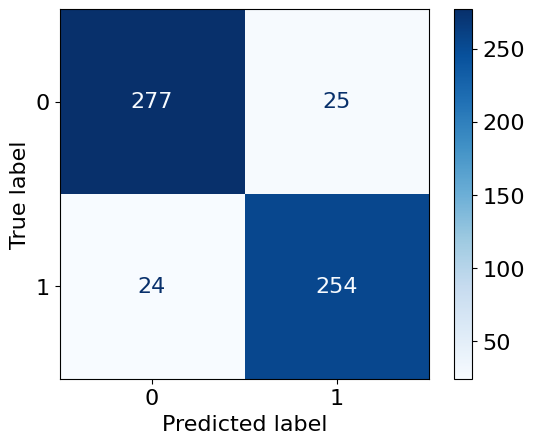

In [1003]:
cm = confusion_matrix(y_test, yhat_SL, labels = [0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels=[0, 1])

# Increase font size
plt.rcParams.update({'font.size': 16})  
disp.plot(cmap='Blues')  
plt.savefig('CM_SL.png',format='png')
plt.show()

In [1001]:
xgb_final = XGBClassifier(n_estimators = 200, min_child_weight = 5, max_depth = 6, learning_rate = 0.1, random_state = 12)
xgb_final.fit(X_imp_arr, y_data)
yhat_xgb = xgb_final.predict(X_imp_test_arr)

print('XGBClassifier --- Accuracy: %.3f' % (accuracy_score(y_test, yhat_xgb) * 100),'%')
print('XGBClassifier --- Matthews Corrcoef: %.3f' % (matthews_corrcoef(y_test, yhat_xgb) * 100),'%')
print('XGBClassifier --- Precision: %.3f' % (precision_score(y_test, yhat_xgb) * 100),'%')
print('XGBClassifier --- Recall: %.3f' % (recall_score(y_test, yhat_xgb) * 100),'%')


XGBClassifier --- Accuracy: 89.655 %
XGBClassifier --- Matthews Corrcoef: 79.378 %
XGBClassifier --- Precision: 87.586 %
XGBClassifier --- Recall: 91.367 %


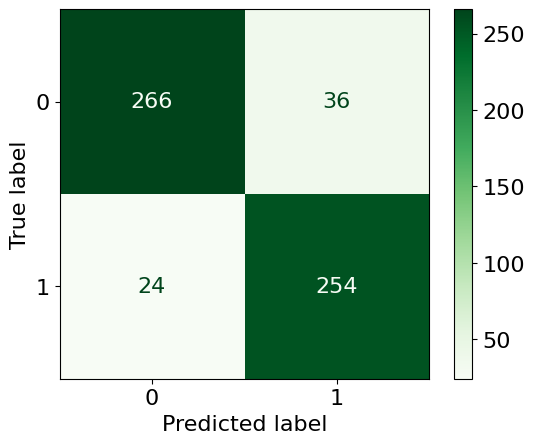

In [1004]:
cm_xgb = confusion_matrix(y_test, yhat_xgb, labels = [0, 1])
disp_xgb = ConfusionMatrixDisplay(confusion_matrix = cm_xgb, display_labels = [0, 1])
plt.rcParams.update({'font.size': 16})  
disp_xgb.plot(cmap='Greens')  
plt.savefig('CM_xgb.png',format='png')
plt.show()